# Classify Song genre from audio data

## Introduction


Over the past few years, streaming services with huge catalogs have become the primary means through which most people listen to their favorite music. But at the same time, the sheer amount of music on offer can mean users might be a bit overwhelmed when trying to look for newer music that suits their tastes.

For this reason, streaming services have looked into means of categorizing music to allow for personalized recommendations. One method involves direct analysis of the raw audio information in a given song, scoring the raw data on a variety of metrics. Today, we'll be examining data compiled by a research group known as The Echo Nest. Our goal is to look through this dataset and classify songs as being either 'Hip-Hop' or 'Rock' - all without listening to a single one ourselves.

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Data Acquisition

To begin with, let's load the metadata about our tracks alongside the track metrics compiled by The Echo Nest. A song is about more than its title, artist, and number of listens. We have another dataset that has musical features of each track such as danceability and acousticness on a scale from -1 to 1. These exist in two different files, which are in different formats - CSV and JSON.

Let's start by creating two pandas DataFrames out of these files that we can merge so we have features and labels for the classification later on.

In [2]:
# Read in track metadata with genre labels
tracks = pd.read_csv('fma-rock-vs-hiphop.csv')
tracks.head()

,track_id,bit_rate,comments,composer,date_created,date_recorded,duration,favorites,genre_top,genres,...,information,interest,language_code,license,listens,lyricist,number,publisher,tags,title
0,135,256000,1,NaN,2008-11-26 01:43:26,2008-11-26 00:00:00,837,0,Rock,"[45, 58]",...,NaN,2484,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1832,NaN,0,NaN,[],Father's Day
1,136,256000,1,NaN,2008-11-26 01:43:35,2008-11-26 00:00:00,509,0,Rock,"[45, 58]",...,NaN,1948,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1498,NaN,0,NaN,[],Peel Back The Mountain Sky
2,151,192000,0,NaN,2008-11-26 01:44:55,NaN,192,0,Rock,[25],...,NaN,701,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,148,NaN,4,NaN,[],Untitled 04
3,152,192000,0,NaN,2008-11-26 01:44:58,NaN,193,0,Rock,[25],...,NaN,637,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,98,NaN,11,NaN,[],Untitled 11
4,153,256000,0,Arc and Sender,2008-11-26 01:45:00,2008-11-26 00:00:00,405,5,Rock,[26],...,NaN,354,en,Attribution-NonCommercial-NoDerivatives (aka M...,424,NaN,2,NaN,[],Hundred-Year Flood


In [3]:
# Read in track metrics with the features
echonest_metrics = pd.read_json('echonest-metrics.json', precise_float=True)
echonest_metrics

,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence
0,2,0.416675,0.675894,0.634476,0.010628,0.177647,0.159310,165.922,0.576661
1,3,0.374408,0.528643,0.817461,0.001851,0.105880,0.461818,126.957,0.269240
2,5,0.043567,0.745566,0.701470,0.000697,0.373143,0.124595,100.260,0.621661
3,10,0.951670,0.658179,0.924525,0.965427,0.115474,0.032985,111.562,0.963590
4,134,0.452217,0.513238,0.560410,0.019443,0.096567,0.525519,114.290,0.894072
...,...,...,...,...,...,...,...,...,...
13124,124857,0.007592,0.790364,0.719288,0.853114,0.720715,0.082550,141.332,0.890461
13125,124862,0.041498,0.843077,0.536496,0.865151,0.547949,0.074001,101.975,0.476845
13126,124863,0.000124,0.609686,0.895136,0.846624,0.632903,0.051517,129.996,0.496667
13127,124864,0.327576,0.574426,0.548327,0.452867,0.075928,0.033388,142.009,0.569274


In [4]:
# Merge the relevant columns of tracks and echonest_metrics
echo_tracks = echonest_metrics.merge(tracks[['genre_top', 'track_id']], on='track_id')

In [5]:
# Inspect the resultant dataframe
echo_tracks.head()

,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,genre_top
0,2,0.416675,0.675894,0.634476,0.010628,0.177647,0.159310,165.922,0.576661,Hip-Hop
1,3,0.374408,0.528643,0.817461,0.001851,0.105880,0.461818,126.957,0.269240,Hip-Hop
2,5,0.043567,0.745566,0.701470,0.000697,0.373143,0.124595,100.260,0.621661,Hip-Hop
3,134,0.452217,0.513238,0.560410,0.019443,0.096567,0.525519,114.290,0.894072,Hip-Hop
4,153,0.988306,0.255661,0.979774,0.973006,0.121342,0.051740,90.241,0.034018,Rock


## Exploratory Data analysis

In [6]:
# Display the number of rows and columns in the dataset
print("Number of rows and columns:", echo_tracks.shape)

Number of rows and columns: (4802, 10)


In [7]:
# Display summary statistics for numerical variables
print(echo_tracks.describe())

            track_id  acousticness  danceability       energy  \
count    4802.000000  4.802000e+03   4802.000000  4802.000000   
mean    30164.871720  4.870600e-01      0.436556     0.625126   
std     28592.013796  3.681396e-01      0.183502     0.244051   
min         2.000000  9.491000e-07      0.051307     0.000279   
25%      7494.250000  8.351236e-02      0.296047     0.450757   
50%     20723.500000  5.156888e-01      0.419447     0.648374   
75%     44240.750000  8.555765e-01      0.565339     0.837016   
max    124722.000000  9.957965e-01      0.961871     0.999768   

       instrumentalness     liveness  speechiness        tempo      valence  
count       4802.000000  4802.000000  4802.000000  4802.000000  4802.000000  
mean           0.604096     0.187997     0.104877   126.687944     0.453413  
std            0.376487     0.150562     0.145934    34.002473     0.266632  
min            0.000000     0.025297     0.023234    29.093000     0.014392  
25%            0.164972 

Looks like there are no null values in the data.

**Inference**:

1. The acousticness feature has a mean value of approximately 0.487, indicating that, on average, the songs in the dataset have a moderate level of acousticness.

2. The danceability feature has a mean value of around 0.437, suggesting that the songs in the dataset have a relatively low danceability score on average.

3. The energy feature has a mean value of approximately 0.625, indicating that, on average, the songs in the dataset are relatively energetic.

4. The instrumentalness feature has a mean value of around 0.604, suggesting that, on average, the songs in the dataset have a high degree of instrumentalness.

5. The liveness feature has a mean value of approximately 0.188, indicating that, on average, the songs in the dataset have a relatively low liveness score.

6. The speechiness feature has a mean value of around 0.105, suggesting that, on average, the songs in the dataset have a low speechiness score.

7. The tempo feature has a mean value of approximately 126.688, indicating that, on average, the songs in the dataset have a moderate tempo.

8. The valence feature has a mean value of around 0.453, suggesting that, on average, the songs in the dataset have a moderate level of valence.

9. The features with the highest variability are instrumentalness (std = 0.376) and energy (std = 0.244), suggesting a wide range of values in these features across the dataset.

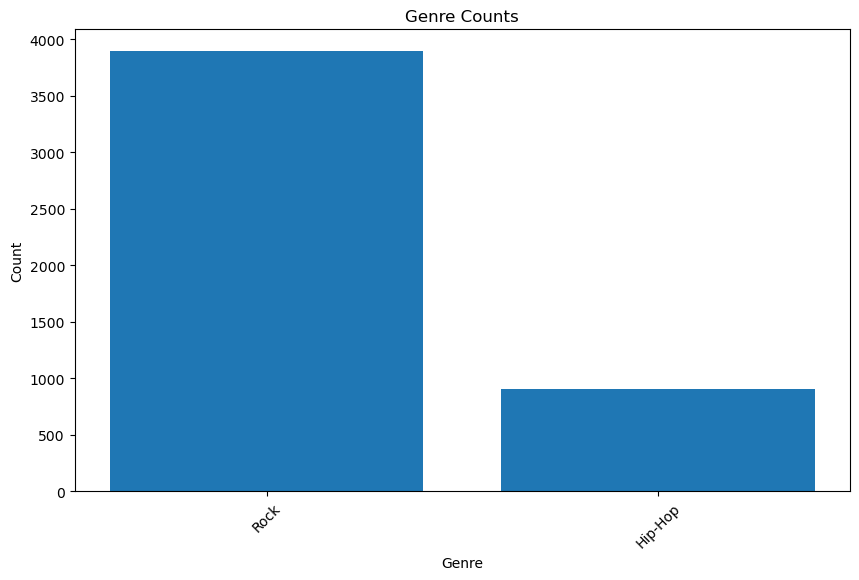

In [8]:
# Calculate genre counts
genre_counts = echo_tracks['genre_top'].value_counts()

# Plot the genre counts
plt.figure(figsize=(10, 6))
plt.bar(genre_counts.index, genre_counts.values)
plt.title('Genre Counts')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

We have 3892 song samples classified as 'Rock' genre and only 910 samples classified as 'Hip-Hop' genre. This indicates an imbalance in the class distribution, with a significantly larger number of samples belonging to the 'Rock' genre compared to the 'Hip-Hop' genre.

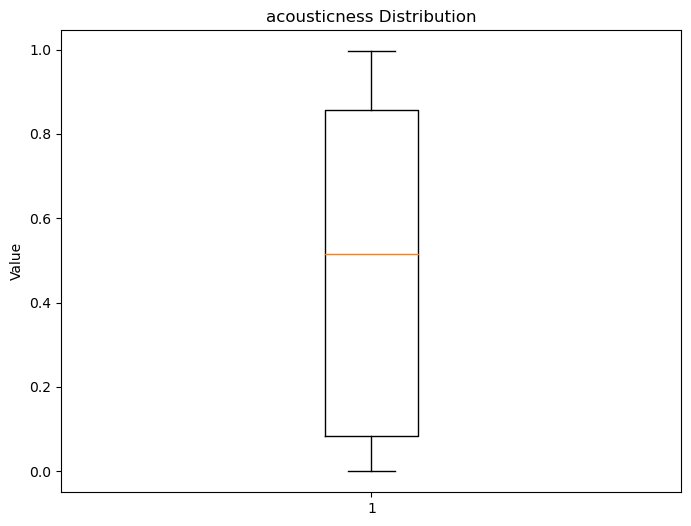

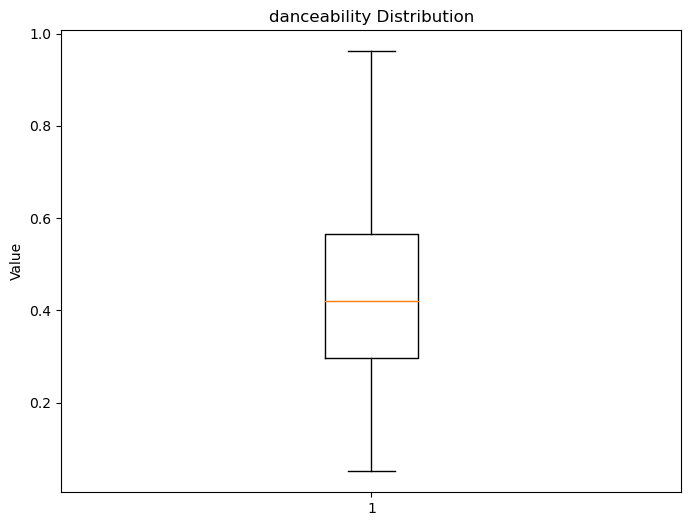

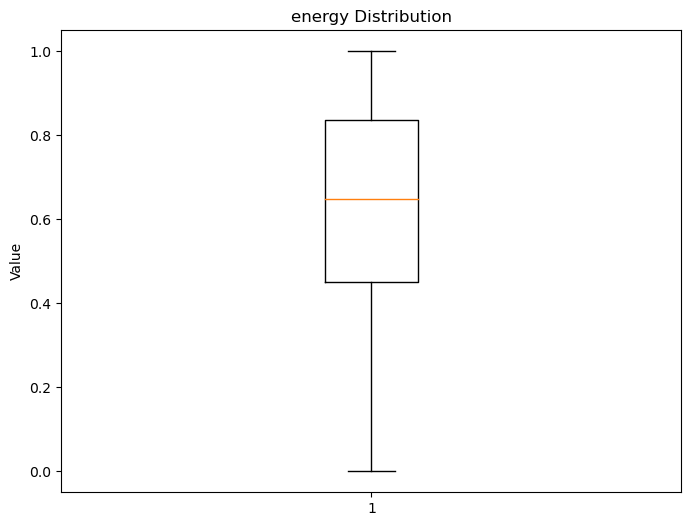

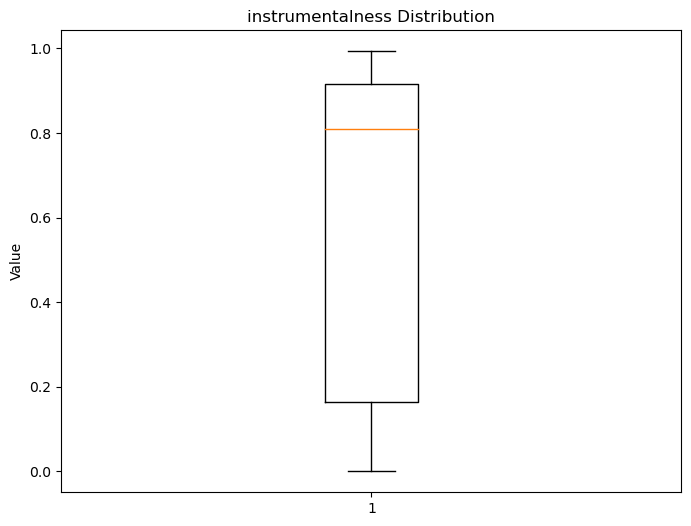

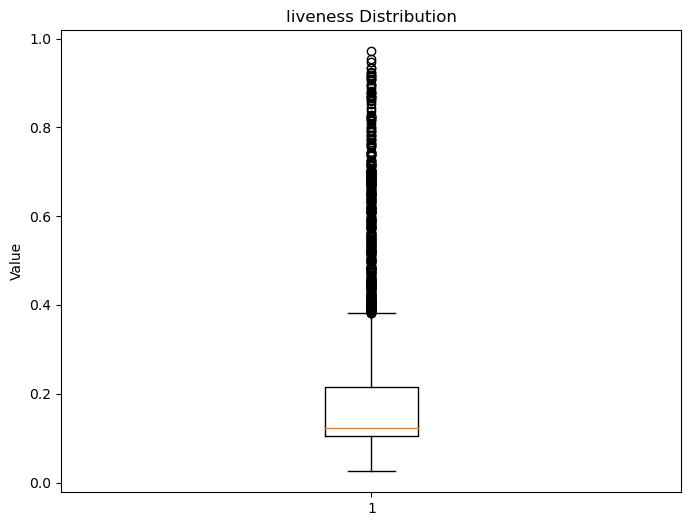

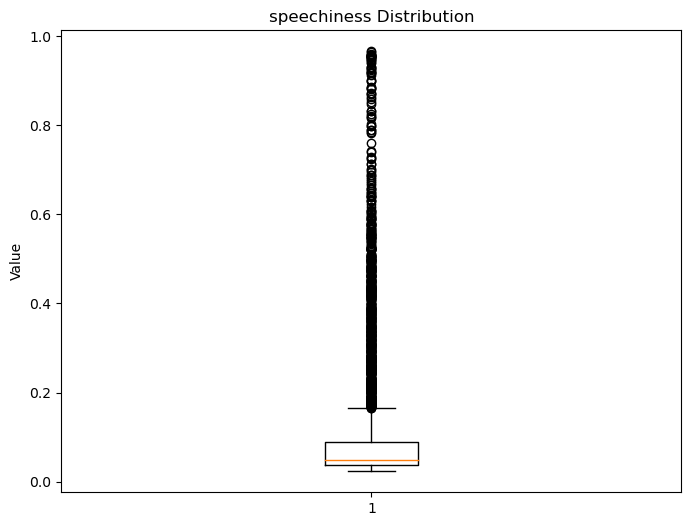

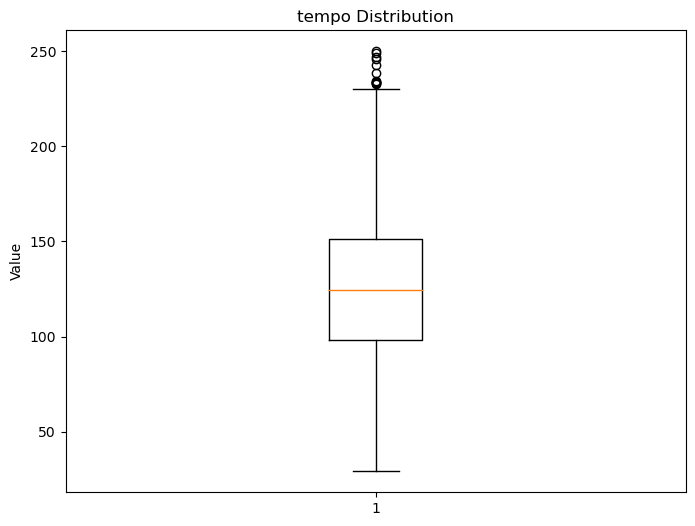

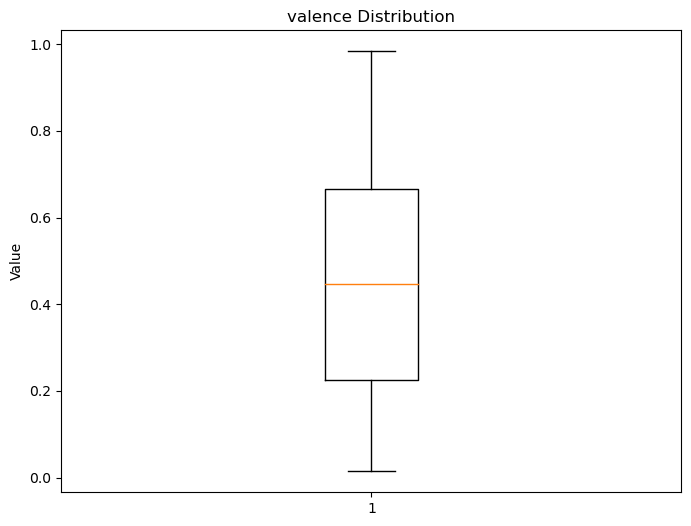

In [9]:
# Visualize the distribution of each numerical feature
numerical_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.boxplot(echo_tracks[col])
    plt.title(col + ' Distribution')
    plt.ylabel('Value')
    plt.show()

From the above plot, we can make the following inferences about the distributions of the features:

The distribution of the liveness,speechiness features have huge number of outliers.These outliers suggest that there are some songs in the dataset that have a significantly higher liveness,speechiness scores compared to the majority of songs.

The distribution of the tempo feature has relatively smaller number of outliers.

Skewness:

Speechiness: The distribution of Speechiness is right-skewed. This means that the majority of songs in the dataset have lower values of speechiness, while a smaller number of songs have higher values. The right-skewness suggests that the songs are predominantly instrumental or have minimal speech content.

Liveness: The distribution of Liveness is also right-skewed. This implies that most songs have lower values of liveness, indicating that they are more likely to be studio recordings or have minimal audience presence. A smaller number of songs have higher values of liveness, indicating live performances or recordings with a more prominent audience presence.

Instrumentalness: The distribution of Instrumentalness is left-skewed. This suggests that the majority of songs in the dataset have higher values of instrumentalness, meaning they are more likely to be instrumental tracks. A smaller number of songs have lower values of instrumentalness, indicating a greater presence of vocals or non-instrumental elements.

In [23]:
# Calculating the variances of the features
echo_tracks.var(numeric_only=True)

track_id            8.175033e+08
acousticness        1.355268e-01
danceability        3.367286e-02
energy              5.956074e-02
instrumentalness    1.417426e-01
liveness            2.266889e-02
speechiness         2.129684e-02
tempo               1.156168e+03
valence             7.109255e-02
dtype: float64

As the feature tempo has higher variance compared to others we could perform normalization using techniques log-normalization to reduce the variance.

In [25]:
# Create a correlation matrix
corr_metrics = echo_tracks.corr(numeric_only=True)
corr_metrics.style.background_gradient()

,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence
track_id,1.000000,-0.372282,0.049454,0.140703,-0.275623,0.048231,-0.026995,-0.025392,0.010070
acousticness,-0.372282,1.000000,-0.028954,-0.281619,0.194780,-0.019991,0.072204,-0.026310,-0.013841
danceability,0.049454,-0.028954,1.000000,-0.242032,-0.255217,-0.106584,0.276206,-0.242089,0.473165
energy,0.140703,-0.281619,-0.242032,1.000000,0.028238,0.113331,-0.109983,0.195227,0.038603
instrumentalness,-0.275623,0.194780,-0.255217,0.028238,1.000000,-0.091022,-0.366762,0.022215,-0.219967
liveness,0.048231,-0.019991,-0.106584,0.113331,-0.091022,1.000000,0.041173,0.002732,-0.045093
speechiness,-0.026995,0.072204,0.276206,-0.109983,-0.366762,0.041173,1.000000,0.008241,0.149894
tempo,-0.025392,-0.026310,-0.242089,0.195227,0.022215,0.002732,0.008241,1.000000,0.052221
valence,0.010070,-0.013841,0.473165,0.038603,-0.219967,-0.045093,0.149894,0.052221,1.000000


We typically want to avoid using variables that have strong correlations with each other --- hence avoiding feature redundancy --- for a few reasons:

    1.To keep the model simple and improve interpretability (with many features, we run the risk of overfitting).
    2.When our datasets are very large, using fewer features can drastically speed up our computation time.


But we didn't find any particularly strong correlations between our features

## Exporting to csv

In [12]:
echo_tracks.to_csv('dataset_part_1.csv', index=False)